## Timescales for thermalization

Let $\ket{\psi(0)} = \ket{k_0}$ and let $\ket{k}$ to be eigenstates of the hamiltonian.

Then the projection of $\ket{\psi(t)}$ onto $\ket{k}$ is $C^{k_0}_k(t)$

We define evolution of the participation entropy as follows 

$$\langle \chi_{\mathrm{ent}}(t) \rangle = \bigg \langle -\ln\bigg (\sum_{k=1}^D |C^{k_0}_k(t)|^4 \bigg) \bigg \rangle$$

The $\langle \cdot \rangle$ denotes average over initial states.

Let the initial state be a random state with $S_z =0$.

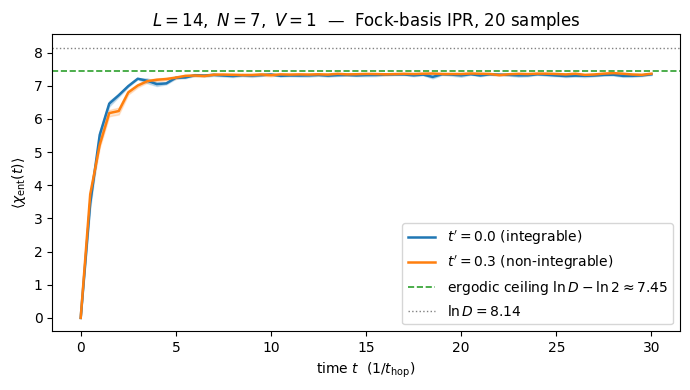

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

n_samples = 20

def load_csv(path):
    df = pd.read_csv(path, comment="#")
    ln_D, ceiling = None, None
    with open(path) as f:
        for line in f:
            if "ln(D)" in line and "ceiling" in line:
                ln_D    = float(line.split("ln(D) =")[1].split()[0])
                ceiling = float(line.split("≈")[1].split()[0])
                break
    return df, ln_D, ceiling

df_int,  ln_D, ceiling = load_csv("results/participation_entropy_L14_tp0.000_Vp0.000.csv")
df_pert, *_            = load_csv("results/participation_entropy_L14_tp0.300_Vp0.000.csv")

fig, ax = plt.subplots(figsize=(7, 4))

for df, tp, color in [(df_int, 0.0, "C0"), (df_pert, 0.3, "C1")]:
    sem = df["chi_ent_std"] / np.sqrt(n_samples)
    label = r"$t'=%.1f$ (%s)" % (tp, "integrable" if tp == 0.0 else "non-integrable")
    ax.fill_between(df["time"], df["chi_ent_mean"] - sem,
                                df["chi_ent_mean"] + sem,
                    alpha=0.2, color=color)
    ax.plot(df["time"], df["chi_ent_mean"], color=color, lw=1.8, label=label)

ax.axhline(ceiling, ls="--", color="C2", lw=1.2,
           label=r"ergodic ceiling $\ln D - \ln 2 \approx %.2f$" % ceiling)
ax.axhline(ln_D, ls=":", color="gray", lw=1.0,
           label=r"$\ln D = %.2f$" % ln_D)

ax.set_xlabel(r"time $t$  ($1/t_\mathrm{hop}$)")
ax.set_ylabel(r"$\langle\chi_\mathrm{ent}(t)\rangle$")
ax.set_title(r"$L=14,\ N=7,\ V=1$  —  Fock-basis IPR, 20 samples")
ax.legend()
plt.tight_layout()
plt.show()


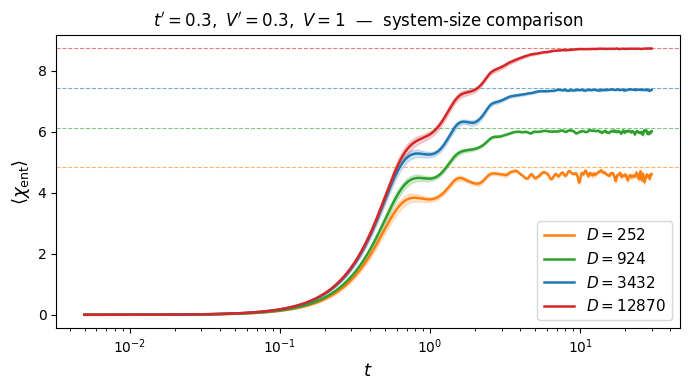

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

n_samples = 20

def load_csv(path):
    df = pd.read_csv(path, comment="#")
    ln_D, ceiling = None, None
    with open(path) as f:
        for line in f:
            if "ln(D)" in line and "ceiling" in line:
                ln_D    = float(line.split("ln(D) =")[1].split()[0])
                ceiling = float(line.split("≈")[1].split()[0])
                break
    return df, ln_D, ceiling

sizes = [10, 12, 14, 16]
colors = ["C1", "C2", "C0", "C3"]

fig, ax = plt.subplots(figsize=(7, 4))

for L, color in zip(sizes, colors):
    path = f"results/participation_entropy_L{L}_tp0.300_Vp0.300.csv"
    df, ln_D, ceiling = load_csv(path)
    D = round(np.exp(ln_D))
    sem  = df["chi_ent_std"] / np.sqrt(n_samples)
    mask = df["time"] > 0
    ax.fill_between(df["time"][mask], (df["chi_ent_mean"] - sem)[mask],
                                      (df["chi_ent_mean"] + sem)[mask],
                    alpha=0.2, color=color)
    ax.plot(df["time"][mask], df["chi_ent_mean"][mask], color=color, lw=1.8,
            label=rf"$D={D}$")
    ax.axhline(ceiling, ls="--", color=color, lw=0.8, alpha=0.6)

ax.set_xscale("log")
ax.set_xlabel(r"$t$", fontsize=13)
ax.set_ylabel(r"$\langle \chi_\mathrm{ent} \rangle$", fontsize=13)
ax.set_title(r"$t'=0.3,\ V'=0.3,\ V=1$  —  system-size comparison")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


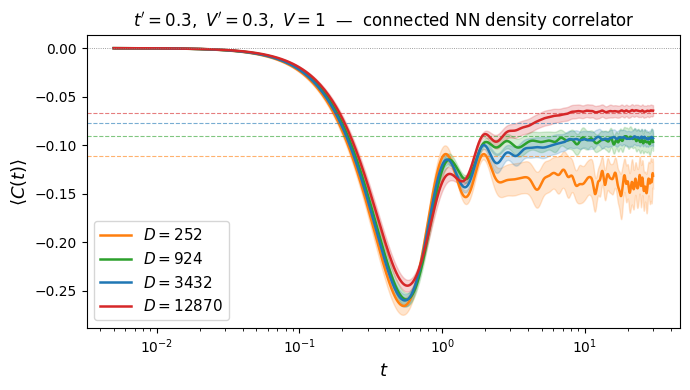

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import comb

n_samples = 20

def load_csv(path):
    df = pd.read_csv(path, comment="#")
    return df

sizes = [10, 12, 14, 16]
colors = ["C1", "C2", "C0", "C3"]

fig, ax = plt.subplots(figsize=(7, 4))

for L, color in zip(sizes, colors):
    path = f"results/participation_entropy_L{L}_tp0.300_Vp0.300.csv"
    df = load_csv(path)
    D = round(comb(L, L // 2))
    plateau = -1.0 / (L - 1)
    sem  = df["C_std"] / np.sqrt(n_samples)
    mask = df["time"] > 0
    ax.fill_between(df["time"][mask], (df["C_mean"] - sem)[mask],
                                      (df["C_mean"] + sem)[mask],
                    alpha=0.2, color=color)
    ax.plot(df["time"][mask], df["C_mean"][mask], color=color, lw=1.8,
            label=rf"$D={D}$")
    ax.axhline(plateau, ls="--", color=color, lw=0.8, alpha=0.6)

ax.axhline(0, color="gray", lw=0.6, ls=":")
ax.set_xscale("log")
ax.set_xlabel(r"$t$", fontsize=13)
ax.set_ylabel(r"$\langle C(t) \rangle$", fontsize=13)
ax.set_title(r"$t'=0.3,\ V'=0.3,\ V=1$  —  connected NN density correlator")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()
